# simple-graphrag feature tests

One section per feature, in pipeline order. Each section is labeled:

- **(no LLM)**: runs instantly, Ollama not needed
- **(needs Ollama)**: makes model calls, so it can take minutes

Run **Setup** first, then jump to any section. Sections 1–6 are quick checks. 7–11 are the slower measurements.

| # | Section | Needs Ollama |
|---|---|---|
| 1 | Unit tests (pytest) | no |
| 2 | Chunking methods | no |
| 3 | Index and extraction | only to rebuild |
| 4 | Knowledge graph | no |
| 5 | OKF wiki | no |
| 6 | Retrieval per mode | embeddings only |
| 7 | Answering, one question | yes |
| 8 | Benchmark | yes (8a: embeddings only) |
| 9 | Wiki token budget sweep | yes |
| 10 | Chunking method comparison | yes (first run) |
| 11 | Saved benchmark runs | no |

## Setup

In [2]:
# the notebook lives in testing/, but the project runs from its root folder (data/, index/, wiki/ are relative)
import os
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "graphrag.py").exists() else Path.cwd().parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

# autoreload picks up edits to the .py files without restarting the kernel
%load_ext autoreload
%autoreload 2

import json
from types import SimpleNamespace

import matplotlib.pyplot as plt
import pandas as pd
import yaml

import chunking
import config
import graphrag
import okf
from testing import bench

QUESTION = "Which vendor maintains the library that caused the outage in the system Priya Raman's team owns?"

print("project root:", ROOT)
print("chat model:  ", config.CHAT_MODEL, "| embed model:", config.EMBED_MODEL)
try:
    import ollama
    models = [m.model for m in ollama.list().models]
    print("ollama:       running,", len(models), "models pulled")
except Exception as error:
    print("ollama:       not reachable, so only the (no LLM) sections will work.", error)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
project root: /Users/student/simple-graphrag
chat model:   qwen2.5:7b | embed model: nomic-embed-text
ollama:       running, 2 models pulled


## 1. Unit tests (no LLM)

Runs the pytest suite in `testing/tests/`. It uses a fake Ollama and a temporary copy of the sample docs, so it takes about a second and never touches your real `index/` or `wiki/`. Run it after changing any `.py` file.

In [3]:
import subprocess
result = subprocess.run([sys.executable, "-m", "pytest", "testing", "-q", "--color=no", "-p", "no:cacheprovider"],
                        capture_output=True, text=True)
print(result.stdout[-3000:] or result.stderr[-3000:])
print("ALL TESTS PASSED" if result.returncode == 0 else "SOME TESTS FAILED, see above")

........................................................................ [ 82%]
...............                                                          [100%]
87 passed in 1.74s

ALL TESTS PASSED


## 2. Chunking methods (no LLM)

How each method splits the documents. `paragraph` is the default; `fixed` is level 1, fixed windows with overlap; `structure` is level 2, split by headings with the heading path kept. See the README for the trade-offs.

In [4]:
# heading lines in the source docs, to spot chunks that are nothing but a heading
headings = {line.strip() for f in config.DATA_DIR.glob("*.md") for line in f.read_text().splitlines() if line.startswith("#")}
rows = []
for method in chunking.METHODS:
    chunks = chunking.load_chunks(method)
    sizes = [len(c["text"]) for c in chunks]
    rows.append({"method": method, "chunks": len(chunks), "min chars": min(sizes), "max chars": max(sizes),
                 "total chars": sum(sizes), "heading-only chunks": sum(c["text"].strip() in headings for c in chunks)})
pd.DataFrame(rows).set_index("method")

,chunks,min chars,max chars,total chars,heading-only chunks
method,,,,,
paragraph,9,30,172,1091,1
fixed,8,60,198,1316,0
structure,8,91,221,1248,0


In [5]:
# the same file, chunked each way
FILE = "vendors.md"
for method in chunking.METHODS:
    print(f"========== {method}")
    for c in chunking.load_chunks(method):
        if c["source"] == FILE:
            print(f"--- {c['id']} ({len(c['text'])} chars)\n{c['text']}\n")

========== paragraph
--- vendors#0 (121 chars)
# Third-party vendors

Redwood is a caching library maintained by Juniper Labs, a small vendor based in Portland, Oregon.

--- vendors#1 (172 chars)
The shipment tracking dashboard uses Brightline Charts, a charting library made by Halcyon Software.

Juniper Labs released a patch for the Redwood memory leak on March 20.

========== fixed
--- vendors#0 (195 chars)
# Third-party vendors Redwood is a caching library maintained by Juniper Labs, a small vendor based in Portland, Oregon. The shipment tracking dashboard uses Brightline Charts, a charting library

--- vendors#1 (139 chars)
uses Brightline Charts, a charting library made by Halcyon Software. Juniper Labs released a patch for the Redwood memory leak on March 20.

========== structure
--- vendors#0 (221 chars)
Third-party vendors

Redwood is a caching library maintained by Juniper Labs, a small vendor based in Portland, Oregon.

The shipment tracking dashboard uses Brightline Charts,

## 3. Index and extraction

Building the index calls the LLM once per new chunk. Extractions are cached, so a rebuild with unchanged chunks is quick. Uncomment to rebuild.

In [6]:
# graphrag.cmd_index(SimpleNamespace())        # full rebuild (needs Ollama for new chunks)
# graphrag.cmd_export_okf(SimpleNamespace())   # rebuild just the wiki from the existing index (no LLM)

from index_store import load_meta
graph, chunks, entity_keys, entity_vectors, chunk_vectors = graphrag.load_index()
print(json.dumps(load_meta(), indent=1))
print(f"\n{len(chunks)} chunks -> {graph.number_of_nodes()} entities, {graph.number_of_edges()} relations")

{
 "chunk_method": "paragraph"
}

9 chunks -> 29 entities, 21 relations


In [7]:
# what extraction got from each chunk
per_chunk = []
for c in chunks:
    ents = [d["name"] for k, d in graph.nodes(data=True) if c["id"] in d["chunks"]]
    rels = [f"{graph.nodes[u]['name']} -{d['relation']}-> {graph.nodes[v]['name']}"
            for u, v, d in graph.edges(data=True) if d["chunk"] == c["id"]]
    per_chunk.append({"chunk": c["id"], "entities": len(ents), "relations": len(rels), "sample relation": rels[0] if rels else ""})
pd.DataFrame(per_chunk).set_index("chunk")

,entities,relations,sample relation
chunk,,,
incidents#0,2,1,Incident log -log of-> spring quarter
incidents#1,4,3,payments API -went down-> March 14
incidents#2,4,2,shipment tracking dashboard -showed-> stale da...
incidents#3,4,2,Dana Okafor -asked-> every team
team#0,6,4,payments API -handles-> customer invoice
team#1,4,2,Marcus Chen -leads-> Beacon team
team#2,3,2,Dana Okafor -joined-> Northwind Freight
vendors#0,3,2,Redwood -maintained by-> Juniper Labs
vendors#1,6,3,shipment tracking dashboard -uses-> Brightline...


## 4. Knowledge graph (no LLM)

In [8]:
degree = sorted(graph.degree, key=lambda pair: pair[1], reverse=True)
pd.DataFrame([{"entity": graph.nodes[k]["name"], "type": graph.nodes[k]["type"], "connections": d,
               "sources": ", ".join(graph.nodes[k]["chunks"])} for k, d in degree[:15]])

,entity,type,connections,sources
0,payments API,system,5,"incidents#1, team#0"
1,shipment tracking dashboard,system,3,"incidents#2, team#1, vendors#1"
2,Dana Okafor,person,3,"incidents#3, team#2"
3,Juniper Labs,organization,3,"vendors#0, vendors#1"
4,Redwood caching library,system,2,incidents#1
5,stale data for twenty minutes,other,2,incidents#2
6,every team,team,2,incidents#3
7,Atlas team,team,2,team#0
8,Redwood,product,2,"vendors#0, vendors#1"
9,Brightline Charts,product,2,vendors#1


In [9]:
# everything the graph knows about one entity
ENTITY = "juniper labs"
for u, v, d in graph.in_edges(ENTITY, data=True):
    print(f"  {graph.nodes[u]['name']} --{d['relation']}--> {graph.nodes[ENTITY]['name']}  [{d['chunk']}]")
for u, v, d in graph.out_edges(ENTITY, data=True):
    print(f"  {graph.nodes[ENTITY]['name']} --{d['relation']}--> {graph.nodes[v]['name']}  [{d['chunk']}]")

  Redwood --maintained by--> Juniper Labs  [vendors#0]
  Juniper Labs --based in--> Portland  [vendors#0]
  Juniper Labs --released a patch for--> Redwood  [vendors#1]


## 5. OKF wiki (no LLM)

One page per entity. Checks that every page has the required `type` field and that every link resolves, and shows the duplicate warnings from `log.md`.

In [10]:
wiki_pages = [p for p in config.WIKI_DIR.rglob("*.md") if p.name not in ("index.md", "log.md")]
front = pd.DataFrame([{**yaml.safe_load(p.read_text().split("---\n", 2)[1]), "path": str(p.relative_to(config.WIKI_DIR))}
                      for p in wiki_pages])
missing_type = front["type"].isna().sum()
broken = [(p.name, t) for p in config.WIKI_DIR.rglob("*.md")
          for t in __import__("re").findall(r"\]\((/[^)]+\.md)\)", p.read_text())
          if not (config.WIKI_DIR / t.lstrip("/")).exists()]
print(f"{len(wiki_pages)} pages, {missing_type} missing `type`, {len(broken)} broken links")
front[["title", "type", "degree", "token_footprint", "sources", "path"]].sort_values("degree", ascending=False)

29 pages, 0 missing `type`, 0 broken links


,title,type,degree,token_footprint,sources,path
21,payments API,system,5,150,"[incidents#1, team#0]",system/payments-api.md
0,Juniper Labs,organization,3,106,"[vendors#0, vendors#1]",organization/juniper-labs.md
22,shipment tracking dashboard,system,3,149,"[incidents#2, team#1, vendors#1]",system/shipment-tracking-dashboard.md
5,Dana Okafor,person,3,108,"[incidents#3, team#2]",person/dana-okafor.md
17,Brightline Charts,product,2,89,[vendors#1],product/brightline-charts.md
24,Atlas team,team,2,62,[team#0],team/atlas-team.md
19,Redwood caching library,system,2,79,[incidents#1],system/redwood-caching-library.md
18,Redwood,product,2,89,"[vendors#0, vendors#1]",product/redwood.md
13,stale data for twenty minutes,other,2,86,[incidents#2],other/stale-data-for-twenty-minutes.md
25,every team,team,2,85,[incidents#3],team/every-team.md


In [11]:
print((config.WIKI_DIR / "system" / "payments-api.md").read_text())

---
type: system
title: payments API
description: a payments system that went down; owned by Atlas team
resource: data/incidents.md
tags:
- system
timestamp: '2026-10-05T22:43:43+00:00'
id: payments api
sources:
- incidents#1
- team#0
degree: 5
token_footprint: 150
---

# payments API

a payments system that went down; owned by Atlas team

## Relations
- **payments API** went down → [March 14](/other/march-14.md) [incidents#1]
- **payments API** handles → [customer invoice](/other/customer-invoice.md) [team#0]
- **payments API** handles → [customer refund](/other/customer-refund.md) [team#0]

## Referenced by
- [Redwood caching library](/system/redwood-caching-library.md) used by → **payments API** [incidents#1]
- [Atlas team](/team/atlas-team.md) owns → **payments API** [team#0]

## Sources
- `incidents#1` from data/incidents.md
- `team#0` from data/team.md



In [12]:
print((config.WIKI_DIR / "log.md").read_text()[-1500:])

---
type: Log
title: Compile log
---

# Compile log

## 2026-10-05T22:36:21+00:00
- compiled 29 pages, 21 relations with qwen2.5:7b
- possible duplicate entities (not merged):
  - Beacon / Beacon team
  - Redwood / Redwood caching library

## 2026-10-05T22:43:43+00:00
- compiled 29 pages, 21 relations with qwen2.5:7b
- possible duplicate entities (not merged):
  - Beacon / Beacon team
  - Redwood / Redwood caching library



## 6. Retrieval per mode (embeddings only)

What each mode would send to the model for one question. Only the question gets embedded; no chat model calls.

In [13]:
index = graphrag.load_index()
retrieval_rows = []
for mode in ("vector", "graph", "wiki"):
    context, trace = graphrag.build_context(QUESTION, index, mode, hops=2, top_entities=5, top_chunks=3, budget=300)
    retrieval_rows.append({"mode": mode, "context chars": len(context), "~tokens": len(context) // 4,
                           "facts": len(trace.get("facts", [])), "passages": len(trace["chunks"]),
                           "wiki pages": len(trace.get("pages", [])), "retrieve ms": round(trace["retrieve_ms"], 2)})
    print(f"==================== {mode}\n{context}\n")
pd.DataFrame(retrieval_rows).set_index("mode")

==================== vector
Source passages:
[vendors#0]
# Third-party vendors

Redwood is a caching library maintained by Juniper Labs, a small vendor based in Portland, Oregon.

[incidents#1]
On March 14, the payments API went down for three hours. The root cause was a memory leak in the Redwood caching library, which the payments API uses to store session data.

[team#0]
# Engineering teams at Northwind Freight

Priya Raman leads the Atlas team. Atlas owns the payments API, which handles every customer invoice and refund.

==================== graph
Facts from the knowledge graph:
Atlas team --owns--> payments API [team#0]
Juniper Labs --based in--> Portland [vendors#0]
Juniper Labs --released a patch for--> Redwood [vendors#1]
Priya Raman --leads--> Atlas team [team#0]
Redwood --maintained by--> Juniper Labs [vendors#0]
Redwood caching library --has--> memory leak [incidents#1]
Redwood caching library --used by--> payments API [incidents#1]
payments API --handles--> customer invoic

,context chars,~tokens,facts,passages,wiki pages,retrieve ms
mode,,,,,,
vector,502,125,0,3,0,0.06
graph,1057,264,10,3,0,2.54
wiki,1235,308,10,0,12,19.60


In [14]:
# how the wiki budget changes what gets packed in
budget_rows = []
for budget in (50, 100, 200, 300):
    _, trace = graphrag.build_context(QUESTION, index, "wiki", hops=2, top_entities=5, top_chunks=3, budget=budget)
    budget_rows.append({"budget": budget, "tokens_used": trace["tokens_used"], "pages": len(trace["pages"]),
                        "pages considered": trace["pages_considered"], "first pages": ", ".join(trace["pages"][:4])})
pd.DataFrame(budget_rows).set_index("budget")

,tokens_used,pages,pages considered,first pages
budget,,,,
50,34,2,12,"Priya Raman, March outage"
100,98,4,12,"Priya Raman, Redwood, March outage, memory leak"
200,196,5,12,"Priya Raman, Redwood, Redwood caching library,..."
300,296,12,12,"Priya Raman, Redwood, Redwood caching library,..."


## 7. Answering, one question (needs Ollama)

In [15]:
bench.warm_up()  # load both models first so the first mode isn't charged for loading
answers = []
for mode in ("graph", "vector", "wiki"):
    result = graphrag.run_query(QUESTION, index, mode)
    print(f"==================== {mode}\n{result['answer']}\n")
    answers.append({"mode": mode, **{k: round(v, 1) for k, v in result["metrics"].items()}})
pd.DataFrame(answers).set_index("mode")[["warm_ms", "retrieve_ms", "prompt_eval_ms", "generate_ms",
                                         "prompt_tokens", "output_tokens", "load_ms", "embed_load_ms"]]

Warming up models...
  Ollama can't keep both in memory, so expect cold calls. Try a smaller CHAT_MODEL or set OLLAMA_MAX_LOADED_MODELS=2 before starting Ollama.
==================== graph
To answer this question, let's chain the facts together:

1. The payments API went down on March 14 due to a memory leak in the Redwood caching library. [incidents#1]
2. The Redwood caching library is used by the payments API to store session data. [incidents#1]
3. The Redwood caching library is maintained by Juniper Labs. [vendors#0]
4. The Atlas team owns the payments API. [team#0]
5. Priya Raman leads the Atlas team. [team#0]

From these facts, we can conclude that Juniper Labs maintains the library (Redwood caching library) that caused the outage in the system Priya Raman's team owns (payments API).

Therefore, the answer is Juniper Labs. [vendors#0, incidents#1, team#0]

==================== vector
The vendor that maintains the library causing the outage is Juniper Labs. This can be deduced by t

,warm_ms,retrieve_ms,prompt_eval_ms,generate_ms,prompt_tokens,output_tokens,load_ms,embed_load_ms
mode,,,,,,,,
graph,25209.2,5.0,3793.2,21376.8,364,177,4.8,4.4
vector,16381.1,0.1,1644.2,14704.6,216,137,5.0,5.7
wiki,23333.8,1.0,3798.2,19503.3,409,180,2.5,2.3


## 8. Benchmark

### 8a. Retrieval only (embeddings only)
Retrieval speed and evidence recall. Fast.

In [16]:
rows, summary = bench.run_bench(retrieval_only=True, runs=5)
pd.DataFrame(summary).round(2)

Warming up models...
  [1/120] run 1  vector  beacon-lead
  [2/120] run 1  wiki    beacon-lead
  [3/120] run 1  graph   beacon-lead
  [4/120] run 1  wiki    outage-date
  [5/120] run 1  graph   outage-date
  [6/120] run 1  vector  outage-date
  [7/120] run 1  graph   redwood-vendor
  [8/120] run 1  vector  redwood-vendor
  [9/120] run 1  wiki    redwood-vendor
  [10/120] run 1  vector  payments-boss
  [11/120] run 1  wiki    payments-boss
  [12/120] run 1  graph   payments-boss
  [13/120] run 1  wiki    fix-date
  [14/120] run 1  graph   fix-date
  [15/120] run 1  vector  fix-date
  [16/120] run 1  graph   chart-maker
  [17/120] run 1  vector  chart-maker
  [18/120] run 1  wiki    chart-maker
  [19/120] run 1  vector  outage-vendor
  [20/120] run 1  wiki    outage-vendor
  [21/120] run 1  graph   outage-vendor
  [22/120] run 1  wiki    vendor-city
  [23/120] run 1  graph   vendor-city
  [24/120] run 1  vector  vendor-city
  [25/120] run 2  wiki    beacon-lead
  [26/120] run 2  graph   

,graph,vector,wiki
n,40.00,40.00,40.00
cold_calls,0.00,0.00,0.00
warm_ms_median,17.02,13.67,13.76
warm_ms_p95,25.94,23.61,18.77
total_ms_median,18.91,15.85,15.74
first_minus_second_ms,0.18,-1.92,-0.08
embed_ms_median,15.77,15.79,15.31
retrieve_ms_median,3.14,0.07,0.41
context_chars_median,1046.00,491.50,1194.50
evidence_recall,1.00,0.94,1.00


### 8b. Full benchmark (needs Ollama)
Retrieval plus answer, all three modes. Takes about 10–15 minutes at 3 runs.

In [17]:
rows, summary = bench.run_bench(runs=3)
summary_table = pd.DataFrame(summary).round(2)
summary_table

Warming up models...
  [1/72] run 1  vector  beacon-lead
  [2/72] run 1  wiki    beacon-lead
  [3/72] run 1  graph   beacon-lead
  [4/72] run 1  wiki    outage-date
  [5/72] run 1  graph   outage-date
  [6/72] run 1  vector  outage-date
  [7/72] run 1  graph   redwood-vendor
  [8/72] run 1  vector  redwood-vendor
  [9/72] run 1  wiki    redwood-vendor
  [10/72] run 1  vector  payments-boss
  [11/72] run 1  wiki    payments-boss
  [12/72] run 1  graph   payments-boss
  [13/72] run 1  wiki    fix-date
  [14/72] run 1  graph   fix-date
  [15/72] run 1  vector  fix-date
  [16/72] run 1  graph   chart-maker
  [17/72] run 1  vector  chart-maker
  [18/72] run 1  wiki    chart-maker
  [19/72] run 1  vector  outage-vendor
  [20/72] run 1  wiki    outage-vendor
  [21/72] run 1  graph   outage-vendor
  [22/72] run 1  wiki    vendor-city
  [23/72] run 1  graph   vendor-city
  [24/72] run 1  vector  vendor-city
  [25/72] run 2  wiki    beacon-lead
  [26/72] run 2  graph   beacon-lead
  [27/72] run 

,graph,vector,wiki
n,24.00,24.00,24.00
cold_calls,0.00,0.00,0.00
warm_ms_median,6205.84,9215.76,7369.15
warm_ms_p95,19424.13,23253.13,19674.60
total_ms_median,6211.32,9221.12,7376.69
first_minus_second_ms,1691.81,-130.83,380.04
embed_ms_median,26.05,24.84,25.59
retrieve_ms_median,3.27,0.08,0.56
context_chars_median,1046.00,491.50,1194.50
evidence_recall,1.00,0.94,1.00


In [18]:
df = pd.DataFrame(rows)
df.pivot_table(index=["id", "type"], columns="mode", values="correct", aggfunc="mean").style.format("{:.0%}")

,mode,graph,vector,wiki
id,type,,,
beacon-lead,simple,100%,100%,100%
chart-maker,multi-hop,100%,100%,100%
fix-date,multi-hop,100%,0%,100%
outage-date,simple,100%,100%,100%
outage-vendor,multi-hop,100%,100%,100%
payments-boss,multi-hop,100%,100%,100%
redwood-vendor,simple,100%,100%,100%
vendor-city,multi-hop,100%,100%,100%


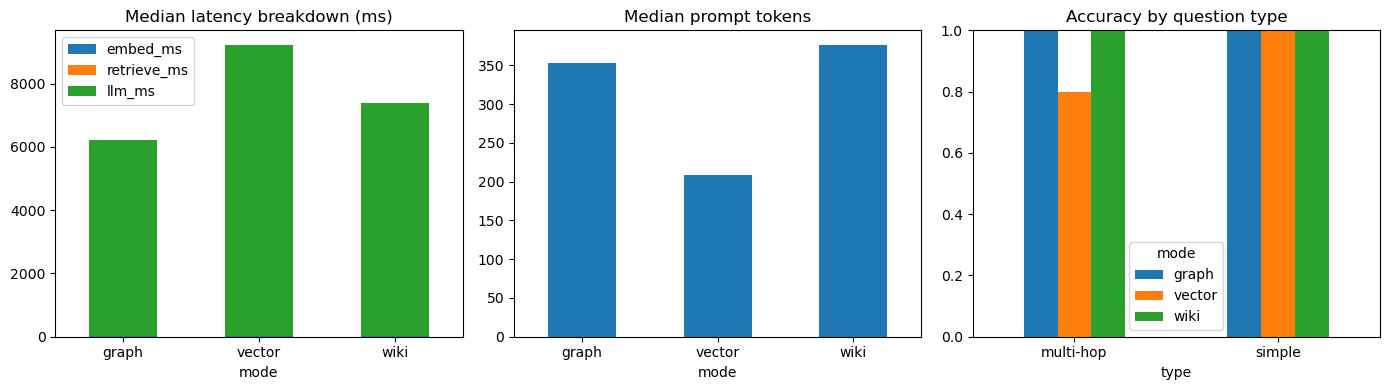

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df.groupby("mode")[["embed_ms", "retrieve_ms", "llm_ms"]].median().plot.bar(
    stacked=True, ax=axes[0], title="Median latency breakdown (ms)", rot=0)
df.groupby("mode")["prompt_tokens"].median().plot.bar(ax=axes[1], title="Median prompt tokens", rot=0)
df.pivot_table(index="type", columns="mode", values="correct", aggfunc="mean").plot.bar(
    ax=axes[2], title="Accuracy by question type", rot=0, ylim=(0, 1))
plt.tight_layout()
plt.show()

In [20]:
df.drop(columns=["answer"]).head(20)  # raw rows

,run,mode,order,id,type,embed_ms,retrieve_ms,llm_ms,total_ms,warm_ms,...,prompt_eval_ms,generate_ms,prompt_tokens,output_tokens,context_chars,cold,evidence_recall,facts,passages,correct
0,1,vector,1,beacon-lead,simple,12.888708,0.036709,3211.455042,3224.397417,3219.065459,...,1744.208000,1458.966000,181,15,405,False,1.0,0,3,True
1,1,wiki,2,beacon-lead,simple,22.265958,0.536542,5505.501500,5528.343292,5523.362375,...,3827.545000,1668.870000,397,17,1244,False,1.0,12,0,True
2,1,graph,3,beacon-lead,simple,22.035292,2.872958,5103.578125,5128.512417,5123.105791,...,3431.605000,1661.124000,376,17,1140,False,1.0,13,3,True
3,1,wiki,1,outage-date,simple,23.513000,0.491666,4948.006250,4972.040000,4967.031792,...,2748.333000,2189.957000,311,21,870,False,1.0,7,0,True
4,1,graph,2,outage-date,simple,31.094250,2.368250,4951.762750,4985.248958,4979.961416,...,2784.935000,2156.534000,320,21,949,False,1.0,7,3,True
5,1,vector,3,outage-date,simple,23.895500,0.061958,3756.620375,3780.595333,3773.282041,...,1640.508000,2100.495000,208,20,530,False,1.0,0,3,True
6,1,graph,1,redwood-vendor,simple,26.749667,2.183459,6286.773000,6315.727208,6310.684832,...,3754.139000,2522.039000,408,23,1250,False,1.0,13,3,True
7,1,vector,2,redwood-vendor,simple,23.043333,0.086250,3013.636500,3036.791584,3031.262833,...,1317.362000,1671.078000,210,17,524,False,1.0,0,3,True
8,1,wiki,3,redwood-vendor,simple,23.922708,0.555041,4941.490958,4965.998792,4961.107084,...,3465.967000,1465.553000,366,15,1156,False,1.0,9,0,True
9,1,vector,1,payments-boss,multi-hop,28.229792,0.091083,10040.468792,10068.831625,10062.903959,...,1638.344000,8384.954000,212,77,477,False,1.0,0,3,True


## 9. Wiki token budget sweep (needs Ollama)

At what budget does wiki-mode accuracy start to drop? Run 8b first so graph and vector show up as reference points.

In [21]:
sweep = []
for budget in [75, 150, 225, 300]:
    _, s = bench.run_bench(modes="wiki", budget=budget, runs=1)
    s = s["wiki"]
    sweep.append({"budget": budget, "accuracy": s["accuracy"], "multi_hop": s["accuracy_multi_hop"],
                  "prompt_tokens": s["prompt_tokens_median"], "warm_ms": s["warm_ms_median"]})
sweep = pd.DataFrame(sweep)
sweep

Warming up models...
  [1/8] run 1  wiki    beacon-lead
  [2/8] run 1  wiki    outage-date
  [3/8] run 1  wiki    redwood-vendor
  [4/8] run 1  wiki    payments-boss
  [5/8] run 1  wiki    fix-date
  [6/8] run 1  wiki    chart-maker
  [7/8] run 1  wiki    outage-vendor
  [8/8] run 1  wiki    vendor-city

KPI                                     wiki
--------------------------------------------
warm latency, median (ms)               2343
warm latency, p95 (ms)                  7112
raw latency incl. loads (ms)            2348
  question embed (ms)                   12.8
  retrieval only (ms)                   0.43
  LLM answer (ms)                       2334
prompt tokens, median                    174
output tokens, median                     47
generation speed (tok/s)                21.7
context size, median (chars)             296
evidence recall                          90%
accuracy, all                            75%
accuracy, simple                        100%
accuracy, multi-hop

,budget,accuracy,multi_hop,prompt_tokens,warm_ms
0,75,0.75,0.6,174.5,2343.435874
1,150,1.00,1.0,237.5,2388.115520
2,225,1.00,1.0,312.0,3411.541979
3,300,1.00,1.0,376.5,4035.682333


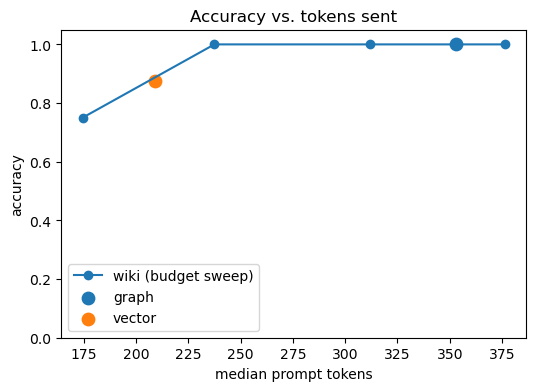

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(sweep["prompt_tokens"], sweep["accuracy"], marker="o", label="wiki (budget sweep)")
for mode in ["graph", "vector"]:
    if "summary" in globals() and mode in summary and "accuracy" in summary[mode]:
        ax.scatter(summary[mode]["prompt_tokens_median"], summary[mode]["accuracy"], s=80, label=mode)
ax.set_xlabel("median prompt tokens"); ax.set_ylabel("accuracy"); ax.set_ylim(0, 1.05)
ax.set_title("Accuracy vs. tokens sent"); ax.legend()
plt.show()

## 10. Chunking method comparison (needs Ollama the first time)

Builds a separate index and wiki per chunking method, then benchmarks each one. `paragraph` reuses `index/` and `wiki/`. The first build of `fixed` and `structure` makes real extraction calls, about a minute or two each; after that they're cached.

In [23]:
from pathlib import Path
folders = {"paragraph": ("index", "wiki"), "fixed": ("index_fixed", "wiki_fixed"), "structure": ("index_structure", "wiki_structure")}
defaults = (config.CHUNK_METHOD, config.INDEX_DIR, config.WIKI_DIR)

chunk_results = {}
try:
    for method, (index_dir, wiki_dir) in folders.items():
        config.CHUNK_METHOD, config.INDEX_DIR, config.WIKI_DIR = method, Path(index_dir), Path(wiki_dir)
        if not (config.INDEX_DIR / "graph.json").exists():
            print(f"=== building {index_dir}/ with {method} chunking")
            graphrag.cmd_index(SimpleNamespace())
        g, c = graphrag.load_index()[:2]
        print(f"=== benchmarking {method}")
        _, s_m = bench.run_bench(runs=1)
        for mode, s in s_m.items():
            chunk_results[(method, mode)] = {"chunks": len(c), "entities": g.number_of_nodes(), "relations": g.number_of_edges(), **s}
finally:
    config.CHUNK_METHOD, config.INDEX_DIR, config.WIKI_DIR = defaults  # put the settings back

chunk_table = pd.DataFrame(chunk_results).T
chunk_table[["chunks", "entities", "relations", "accuracy", "accuracy_multi_hop", "evidence_recall",
             "prompt_tokens_median", "warm_ms_median"]]

=== benchmarking paragraph
Warming up models...
  [1/24] run 1  vector  beacon-lead
  [2/24] run 1  wiki    beacon-lead
  [3/24] run 1  graph   beacon-lead
  [4/24] run 1  wiki    outage-date
  [5/24] run 1  graph   outage-date
  [6/24] run 1  vector  outage-date
  [7/24] run 1  graph   redwood-vendor
  [8/24] run 1  vector  redwood-vendor
  [9/24] run 1  wiki    redwood-vendor
  [10/24] run 1  vector  payments-boss
  [11/24] run 1  wiki    payments-boss
  [12/24] run 1  graph   payments-boss
  [13/24] run 1  wiki    fix-date
  [14/24] run 1  graph   fix-date
  [15/24] run 1  vector  fix-date
  [16/24] run 1  graph   chart-maker
  [17/24] run 1  vector  chart-maker
  [18/24] run 1  wiki    chart-maker
  [19/24] run 1  vector  outage-vendor
  [20/24] run 1  wiki    outage-vendor
  [21/24] run 1  graph   outage-vendor
  [22/24] run 1  wiki    vendor-city
  [23/24] run 1  graph   vendor-city
  [24/24] run 1  vector  vendor-city

KPI                                    graph        vector  

chunks  entities  relations  accuracy  accuracy_multi_hop  \
paragraph graph      9.0      29.0       21.0     1.000                 1.0   
          vector     9.0      29.0       21.0     0.875                 0.8   
          wiki       9.0      29.0       21.0     1.000                 1.0   
fixed     graph      8.0      28.0       19.0     1.000                 1.0   
          vector     8.0      28.0       19.0     1.000                 1.0   
          wiki       8.0      28.0       19.0     1.000                 1.0   
structure graph      8.0      26.0       22.0     0.875                 0.8   
          vector     8.0      26.0       22.0     0.625                 0.4   
          wiki       8.0      26.0       22.0     0.625                 0.6   

                  evidence_recall  prompt_tokens_median  warm_ms_median  
paragraph graph          1.000000                 353.0     3433.292708  
          vector         0.937500                 209.0     5238.445958  
          wiki           1.000000                 376.5     3936.072874  
fixed     graph          1.000000                 382.0    10373.153750  
          vector         0.958333                 229.5     6600.707209  
          wiki           1.000000                 391.5     7023.637791  
structure graph          1.000000                 353.5    11488.115645  
          vector         0.895833                 220.0     7758.836750  
          wiki           1.000000                 371.0     6866.075500

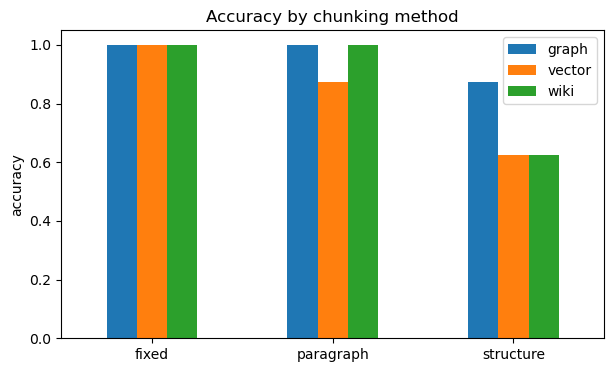

In [24]:
chunk_table["accuracy"].unstack().plot.bar(rot=0, ylim=(0, 1.05), title="Accuracy by chunking method", figsize=(7, 4))
plt.ylabel("accuracy"); plt.show()

## 11. Saved benchmark runs (no LLM)

Every benchmark run is saved to `testing/benchmark/results/`. Use this to compare models, chunking methods or settings over time.

In [25]:
saved = []
for path in sorted(bench.RESULTS_DIR.glob("bench-*.json")):
    blob = json.loads(path.read_text())
    for mode, s in blob["summary"].items():
        saved.append({"file": path.stem, "mode": mode, **blob["config"], **s})
pd.DataFrame(saved)

,file,mode,chat_model,embed_model,chunk_chars,runs,hops,top_entities,top_chunks,retrieval_only,...,prompt_tokens_median,output_tokens_median,generate_tok_per_s,correct_per_1k_prompt_tokens,stable_questions,budget,index_dir,chunk_method,chunk_count,chunk_overlap
0,bench-20261005-133737-retrieval,graph,qwen2.5:7b,nomic-embed-text,200,5,2,5,3,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,bench-20261005-133737-retrieval,vector,qwen2.5:7b,nomic-embed-text,200,5,2,5,3,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,bench-20261005-134647-retrieval,graph,qwen2.5:7b,nomic-embed-text,200,5,2,5,3,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bench-20261005-134647-retrieval,vector,qwen2.5:7b,nomic-embed-text,200,5,2,5,3,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,bench-20261005-135356,graph,qwen2.5:7b,nomic-embed-text,200,3,2,5,3,False,...,353.0,56.0,9.218972,2.839901,1.0,NaN,NaN,NaN,NaN,NaN
5,bench-20261005-135356,vector,qwen2.5:7b,nomic-embed-text,200,3,2,5,3,False,...,209.0,75.0,9.155937,4.350528,1.0,NaN,NaN,NaN,NaN,NaN
6,bench-20261006-155635-retrieval,graph,qwen2.5:7b,nomic-embed-text,200,5,2,5,3,True,...,NaN,NaN,NaN,NaN,NaN,300.0,index,paragraph,NaN,NaN
7,bench-20261006-155635-retrieval,vector,qwen2.5:7b,nomic-embed-text,200,5,2,5,3,True,...,NaN,NaN,NaN,NaN,NaN,300.0,index,paragraph,NaN,NaN
8,bench-20261006-155635-retrieval,wiki,qwen2.5:7b,nomic-embed-text,200,5,2,5,3,True,...,NaN,NaN,NaN,NaN,NaN,300.0,index,paragraph,NaN,NaN
9,bench-20261006-185918,graph,qwen2.5:7b,nomic-embed-text,200,3,2,5,3,False,...,353.0,56.0,0.461925,2.839901,1.0,300.0,index,paragraph,NaN,NaN
